In [60]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [61]:
df = pd.read_csv('1d-data.csv', sep=',')
df["Import net"] = ((df["Import T1 kWh"] + df["Import T2 kWh"])- (df["Import T1 kWh"].shift(1) + df["Import T2 kWh"].shift(1))).shift(-1)
df["Solar yield"] = ((df["Export T1 kWh"] + df["Export T2 kWh"])- (df["Export T1 kWh"].shift(1) + df["Export T2 kWh"].shift(1))).shift(-1)
df["Delta"] = df["Import net"] - df["Solar yield"]
df = df.iloc[:-1]
df["time"] = pd.to_datetime(df["time"])
print(df)

#334 dagen dus net geen jaar!

          time  Import T1 kWh  Import T2 kWh  Export T1 kWh  Export T2 kWh  \
0   2025-05-01      35256.697      20143.177       4924.212      11032.624   
1   2025-05-02      35266.032      20144.997       4924.212      11103.918   
2   2025-05-03      35275.846      20147.183       4924.212      11164.626   
3   2025-05-04      35288.091      20147.183       4974.089      11164.626   
4   2025-05-05      35305.185      20147.183       5002.348      11164.626   
..         ...            ...            ...            ...            ...   
330 2026-03-27      42233.074      23121.197       7295.527      17586.684   
331 2026-03-28      42257.945      23133.207       7295.527      17614.521   
332 2026-03-29      42291.824      23133.207       7336.900      17614.521   
333 2026-03-30      42325.523      23133.207       7367.666      17614.521   
334 2026-03-31      42345.219      23143.643       7367.666      17650.078   

     L1 max W  L2 max W  L3 max W  Import net  Solar yield   De

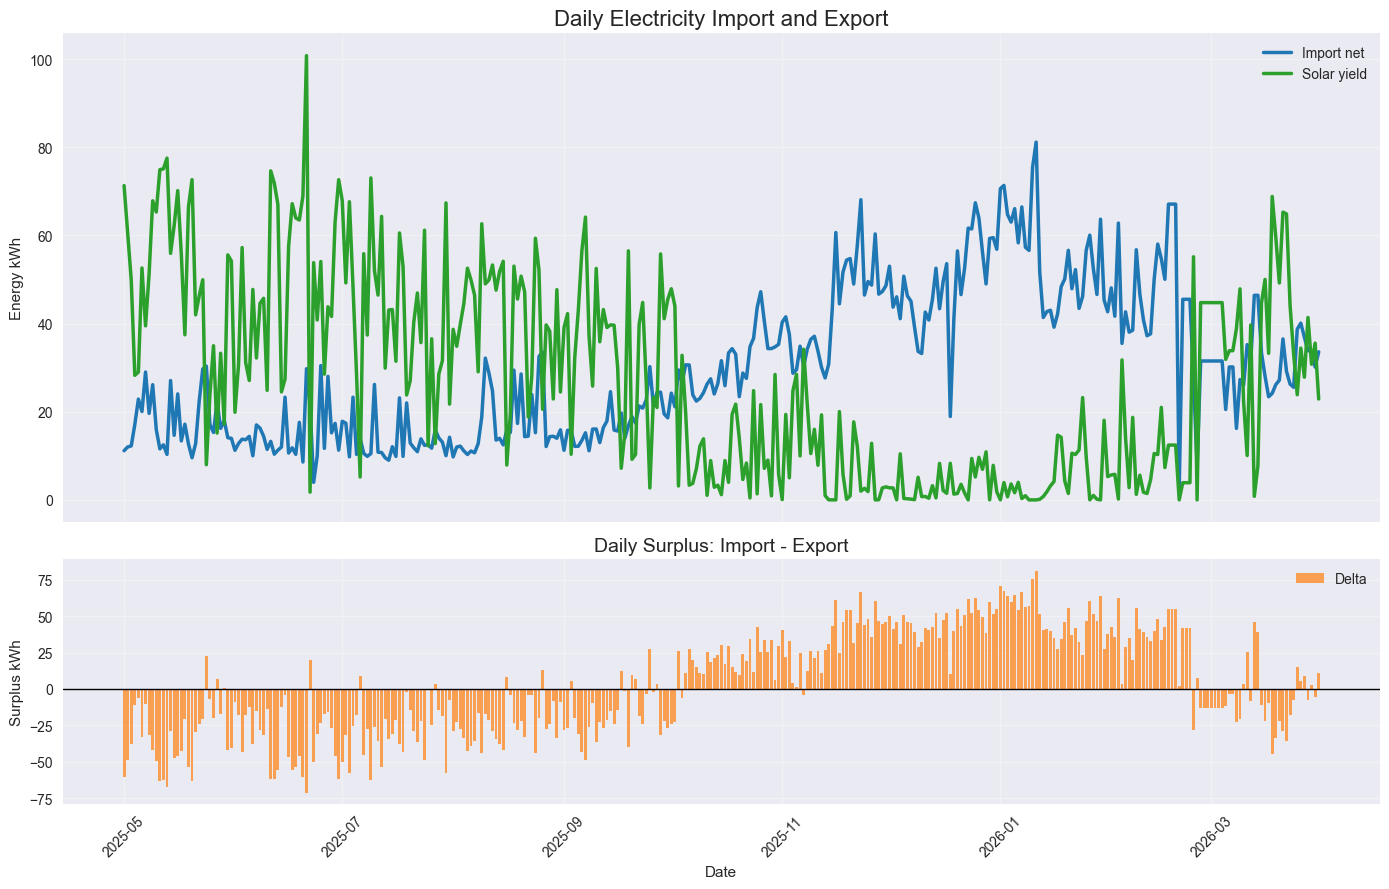

In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(df["time"], df["Import net"], label="Import net", linewidth=2.5, color="#1f77b4")
ax1.plot(df["time"], df["Solar yield"], label="Solar yield", linewidth=2.5, color="#2ca02c")
ax1.set_title("Daily Electricity Import and Export", fontsize=16)
ax1.set_ylabel("Energy kWh")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(df["time"], df["Delta"], label="Delta", color="#ff7f0e", alpha=0.7)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_title("Daily Surplus: Import - Export", fontsize=14)
ax2.set_xlabel("Date")
ax2.set_ylabel("Surplus kWh")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
df[["Import net", "Solar yield", "Delta"]].describe()

,Import net,Solar yield,Delta
count,335.000000,335.000000,335.000000
mean,30.216660,27.115806,3.100854
std,16.798728,22.698633,36.090450
min,2.320000,0.000000,-71.023000
25%,15.213000,5.068500,-26.217500
50%,27.567000,23.930000,-1.193000
75%,42.696000,44.748500,35.839000
max,81.161000,100.778000,81.161000


In [64]:
total_import = df["Import net"].sum()
total_solar = df["Solar yield"].sum()
total_delta = df["Delta"].sum()

print(f"Total import: {total_import:.2f} kWh")
print(f"Total solar yield: {total_solar:.2f} kWh")
print(f"Total delta: {total_delta:.2f} kWh")

Total import: 10122.58 kWh
Total solar yield: 9083.80 kWh
Total delta: 1038.79 kWh


           Import net  Solar yield     Delta
time                                        
May           551.194     1544.259  -993.065
June          443.369     1448.440 -1005.071
July          420.102     1302.605  -882.503
August        545.535     1280.325  -734.790
September     532.384     1029.107  -496.723
October       939.730      385.922   553.808
November     1304.435      280.014  1024.421
December     1511.004      107.260  1403.744
January      1703.525      149.449  1554.076
February     1208.834      381.052   827.782
March         962.469     1175.362  -212.893


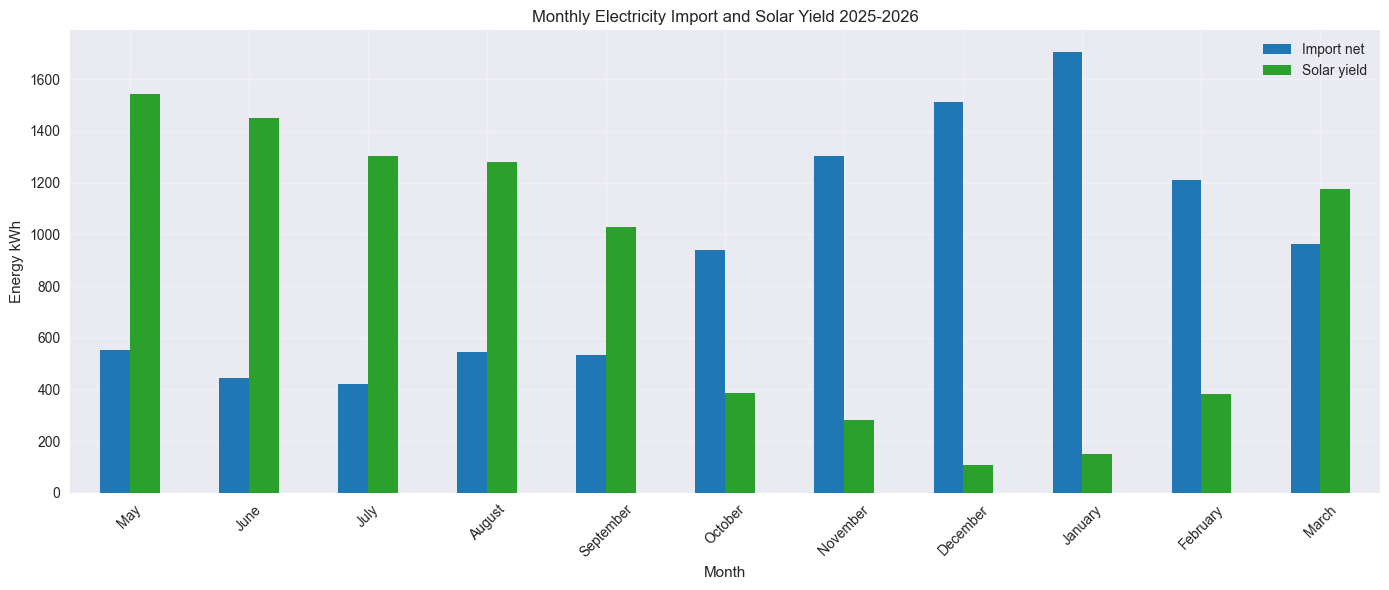

In [65]:
df["time"] = pd.to_datetime(df["time"])

monthly = df.resample("ME", on="time")[["Import net", "Solar yield", "Delta"]].sum()
monthly.index = monthly.index.strftime("%B")
print(monthly)

monthly[["Import net", "Solar yield"]].plot(
    kind="bar",
    figsize=(14, 6),
    color=["#1f77b4", "#2ca02c"]
)

plt.title("Monthly Electricity Import and Solar Yield 2025-2026")
plt.xlabel("Month")
plt.ylabel("Energy kWh")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

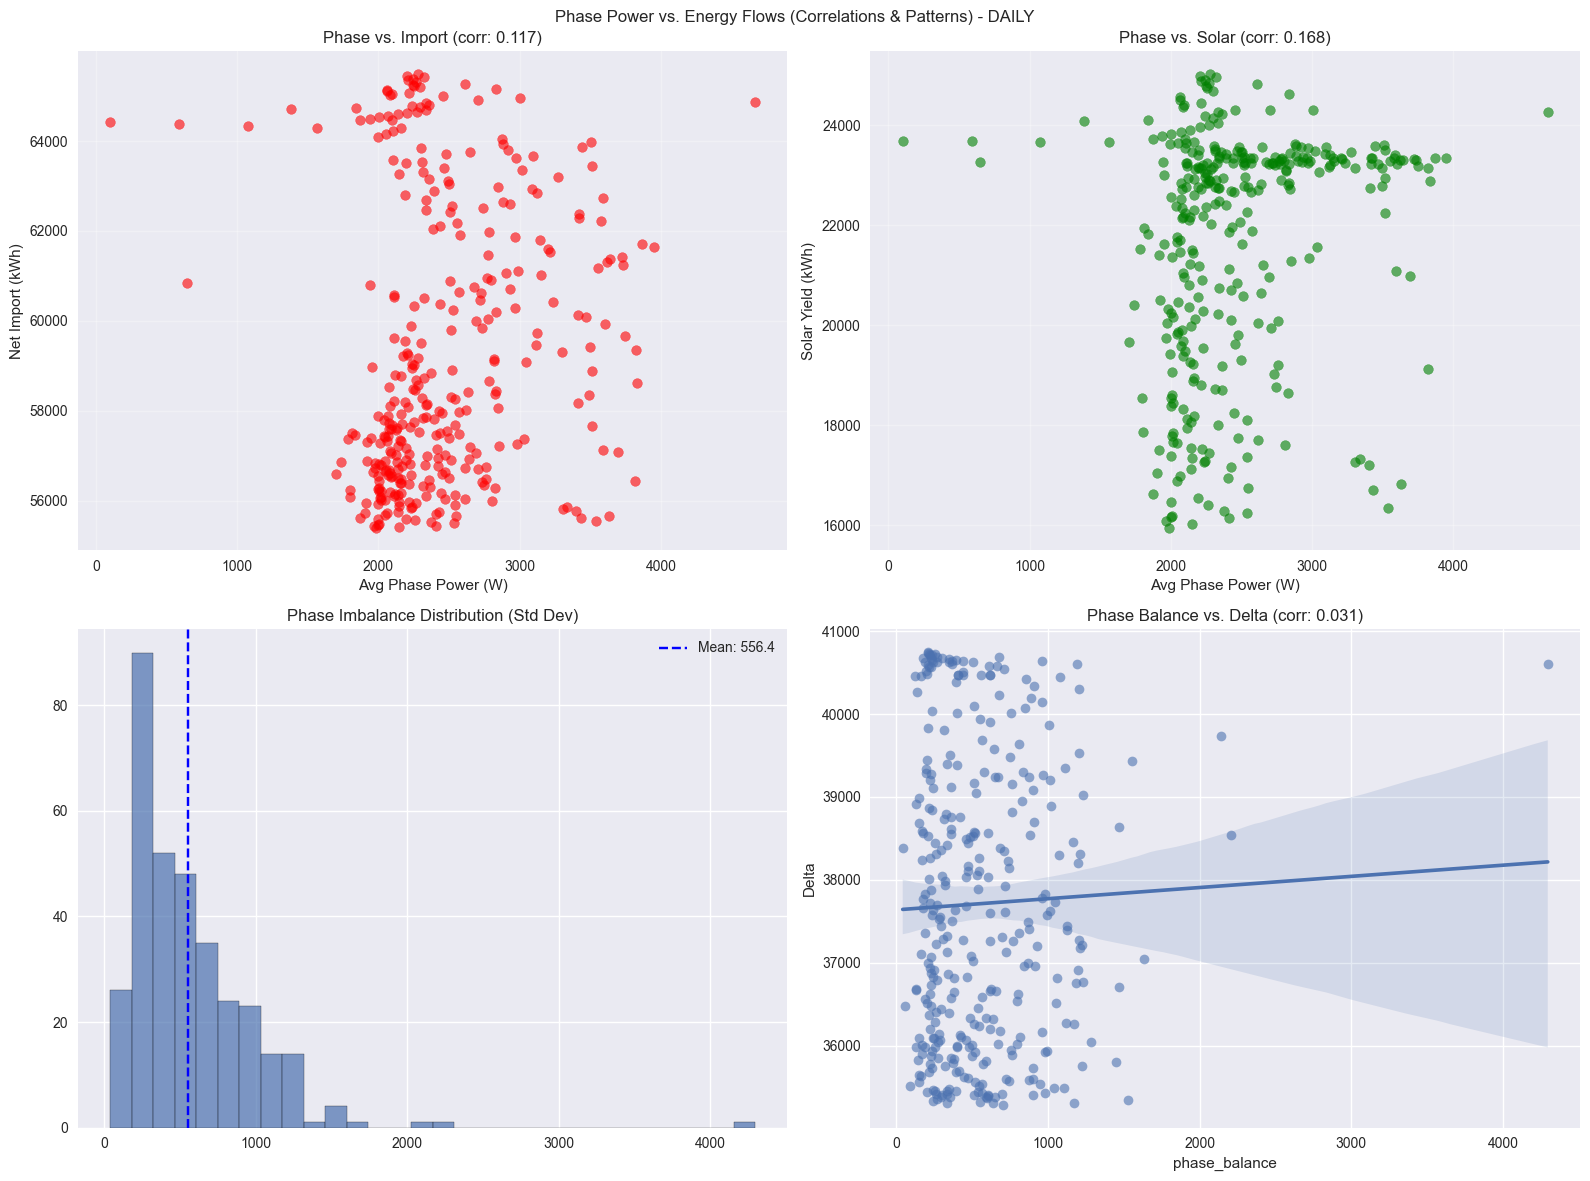

Daily Phase Insights:
                         Metric   Value
0            Phase-Import Corr   0.117
1             Phase-Solar Corr   0.168
2           Phase Balance Mean  556.4W
3  Imbalanced Days (>500W std)     157
Top L1-dominant days:
           date  L1_share  Import net  phase_balance
299 2026-02-24  1.092105   64430.467     210.383776
23  2025-05-24  0.588419   55803.757    2209.139501
273 2026-01-29  0.583953   63199.449    2139.418223
67  2025-07-07  0.547814   56487.000    1206.693140
217 2025-12-04  0.543913   60279.422    1632.829140
159 2025-10-07  0.539246   58055.088    1524.258618
250 2026-01-06  0.535488   61983.396    1465.831164
266 2026-01-22  0.524053   62841.897    1555.605670
124 2025-09-02  0.512085   57371.318    1444.793065
37  2025-06-07  0.511352   56026.958    1212.293831
Feb 24 L1 vs L2/L3 peaks:
Empty DataFrame
Columns: [time, L1 max W, L2 max W, L3 max W, Import T1 kWh]
Index: []

L1-Import T1 corr: 0.087


In [66]:
daily_df = df.groupby(df['time'].dt.date).agg({
    'Import T1 kWh': 'sum', 'Import T2 kWh': 'sum',
    'Export T1 kWh': 'sum', 'Export T2 kWh': 'sum',
    'L1 max W': 'max', 'L2 max W': 'max', 'L3 max W': 'max'
}).reset_index()

daily_df['Import net'] = daily_df['Import T1 kWh'] + daily_df['Import T2 kWh']
daily_df['Solar yield'] = daily_df['Export T1 kWh'] + daily_df['Export T2 kWh']
daily_df['Delta'] = daily_df['Import net'] - daily_df['Solar yield']
daily_df['avg_phase'] = daily_df[['L1 max W', 'L2 max W', 'L3 max W']].mean(axis=1)
daily_df['date'] = pd.to_datetime(daily_df['time'])
phase_cols = ['L1 max W', 'L2 max W', 'L3 max W']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase Power vs. Energy Flows (Correlations & Patterns) - DAILY')

#Phase power vs. Net Import
axes[0,0].scatter(daily_df['avg_phase'], daily_df['Import net'], alpha=0.6, color='red')
corr_import = daily_df['avg_phase'].corr(daily_df['Import net'])
axes[0,0].set_xlabel('Avg Phase Power (W)')
axes[0,0].set_ylabel('Net Import (kWh)')
axes[0,0].set_title(f'Phase vs. Import (corr: {corr_import:.3f})')
axes[0,0].grid(True, alpha=0.3)

# Phase power vs. Solar Yield 
axes[0,1].scatter(daily_df['avg_phase'], daily_df['Solar yield'], alpha=0.6, color='green')
corr_solar = daily_df['avg_phase'].corr(daily_df['Solar yield'])
axes[0,1].set_xlabel('Avg Phase Power (W)')
axes[0,1].set_ylabel('Solar Yield (kWh)')
axes[0,1].set_title(f'Phase vs. Solar (corr: {corr_solar:.3f})')
axes[0,1].grid(True, alpha=0.3)

# Phase balance 
daily_df['phase_balance'] = daily_df[phase_cols].std(axis=1)
axes[1,0].hist(daily_df['phase_balance'], bins=30, edgecolor='black', alpha=0.7)
axes[1,0].axvline(daily_df['phase_balance'].mean(), color='blue', linestyle='--', label=f'Mean: {daily_df["phase_balance"].mean():.1f}')
axes[1,0].set_title('Phase Imbalance Distribution (Std Dev)')
axes[1,0].legend()

# Delta vs. Phase Balance 
sns.regplot(data=daily_df, x='phase_balance', y='Delta', ax=axes[1,1], scatter_kws={'alpha':0.6})
corr_balance_delta = daily_df['phase_balance'].corr(daily_df['Delta'])
axes[1,1].set_title(f'Phase Balance vs. Delta (corr: {corr_balance_delta:.3f})')

plt.tight_layout()
plt.show()

insights = pd.DataFrame({
    'Metric': ['Phase-Import Corr', 'Phase-Solar Corr', 'Phase Balance Mean', 'Imbalanced Days (>500W std)'],
    'Value': [f"{corr_import:.3f}", f"{corr_solar:.3f}", f"{daily_df['phase_balance'].mean():.1f}W", f"{(daily_df['phase_balance'] > 500).sum()}"]
})
print("Daily Phase Insights:\n", insights)
# Find L1-dominant days
daily_df['L1_share'] = daily_df['L1 max W'] / daily_df[['L1 max W','L2 max W','L3 max W']].sum(axis=1)
print("Top L1-dominant days:\n", daily_df.nlargest(10, 'L1_share')[['date', 'L1_share', 'Import net', 'phase_balance']])

worst_day = df[df['time'].dt.date == pd.to_datetime('2026-02-24')]
print("Feb 24 L1 vs L2/L3 peaks:")
print(worst_day[['time', 'L1 max W', 'L2 max W', 'L3 max W', 'Import T1 kWh']].tail(20))
print(f"\nL1-Import T1 corr: {df['L1 max W'].corr(df['Import T1 kWh']):.3f}")

Lage corr, solar covered meeste van dag gebruik, beetje meer import van net. 
Lage corr beetje meer opbrengst maar zo laag dat eik goeie balans is. 
Phase meestal in balans maar zijn pieken. 


In [67]:
print("Phase-Tariff corrs:")
print(f"L1-T1: {df['L1 max W'].corr(df['Import T1 kWh']):.3f}")
print(f"L1-T2: {df['L1 max W'].corr(df['Import T2 kWh']):.3f}")
print(f"L2-T1: {df['L2 max W'].corr(df['Import T1 kWh']):.3f}")

l1_spikes = df.nlargest(5, 'L1 max W')[['time', 'L1 max W', 'L2 max W', 'L3 max W', 'Import net']]
print("\nTop L1 spikes :\n", l1_spikes)


# Confirm pattern (weekends? evenings?)
l1_ev_days = daily_df.nlargest(10, 'L1 max W')
print("L1-dominant days by weekday:\n",
      l1_ev_days['date'].dt.day_name().value_counts())

Phase-Tariff corrs:
L1-T1: 0.087
L1-T2: 0.072
L2-T1: 0.097

Top L1 spikes :
           time  L1 max W  L2 max W  L3 max W  Import net
23  2025-05-24      5833      2331      1749      30.346
273 2026-01-29      5735      2226      1860      63.672
210 2025-11-27      5234      2383      3193      60.327
266 2026-01-22      4913      2082      2380      52.238
178 2025-10-26      4855      3474      3166      47.213
L1-dominant days by weekday:
 date
Thursday    4
Friday      2
Tuesday     2
Saturday    1
Sunday      1
Name: count, dtype: int64


Eh die phase 1 is wel heel hoog afentoe.

Hierboven daily data, hieronder 15m interval dus per dag. Pas op met df zelfde benaming. 

In [68]:
df = pd.read_csv('15m_data.csv', sep=',')
df["Import net"] = ((df["Import T1 kWh"] + df["Import T2 kWh"])- (df["Import T1 kWh"].shift(1) + df["Import T2 kWh"].shift(1))).shift(-1)
df["Solar yield"] = ((df["Export T1 kWh"] + df["Export T2 kWh"])- (df["Export T1 kWh"].shift(1) + df["Export T2 kWh"].shift(1))).shift(-1)
df["Delta"] = df["Import net"] - df["Solar yield"]
df = df.iloc[:-1]
df["time"] = pd.to_datetime(df["time"])
print(df)


                     time  Import T1 kWh  Import T2 kWh  Export T1 kWh  \
0     2025-05-01 00:00:00      35256.697      20143.177       4924.212   
1     2025-05-01 00:15:00      35256.862      20143.177       4924.212   
2     2025-05-01 00:30:00      35257.038      20143.177       4924.212   
3     2025-05-01 00:45:00      35257.229      20143.177       4924.212   
4     2025-05-01 01:00:00      35257.411      20143.177       4924.212   
...                   ...            ...            ...            ...   
32250 2026-04-01 22:30:00      42386.004      23160.193       7367.666   
32251 2026-04-01 22:45:00      42386.809      23160.193       7367.666   
32252 2026-04-01 23:00:00      42387.012      23160.193       7367.666   
32253 2026-04-01 23:15:00      42388.133      23160.193       7367.666   
32254 2026-04-01 23:30:00      42388.648      23160.193       7367.666   

       Export T2 kWh  L1 max W  L2 max W  L3 max W  Import net  Solar yield  \
0          11032.624       441  

In [69]:
df["date"] = df["time"].dt.date
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour

summer = df[df["month"].isin([6, 7, 8])].copy()
night = summer[(summer["hour"] >= 21) | (summer["hour"] < 7)].copy()
night["night_date"] = night["time"].dt.date
night.loc[night["hour"] < 7, "night_date"] = (night.loc[night["hour"] < 7, "time"] - pd.Timedelta(days=1)).dt.date

night_consumption = night.groupby("night_date")["Import net"].sum()
print(night_consumption)



night_date
2025-05-31     5.043
2025-06-01     8.844
2025-06-02    11.158
2025-06-03     9.035
2025-06-04    10.586
               ...  
2025-08-27    10.684
2025-08-28    10.537
2025-08-29    11.059
2025-08-30    10.470
2025-08-31     3.504
Name: Import net, Length: 93, dtype: float64


Average night battery need: 10.8537311827952 kWh
Median night battery need: 9.786000000000058 kWh
Max night battery need: 24.415000000000873 kWh


<Figure size 1400x500 with 0 Axes>

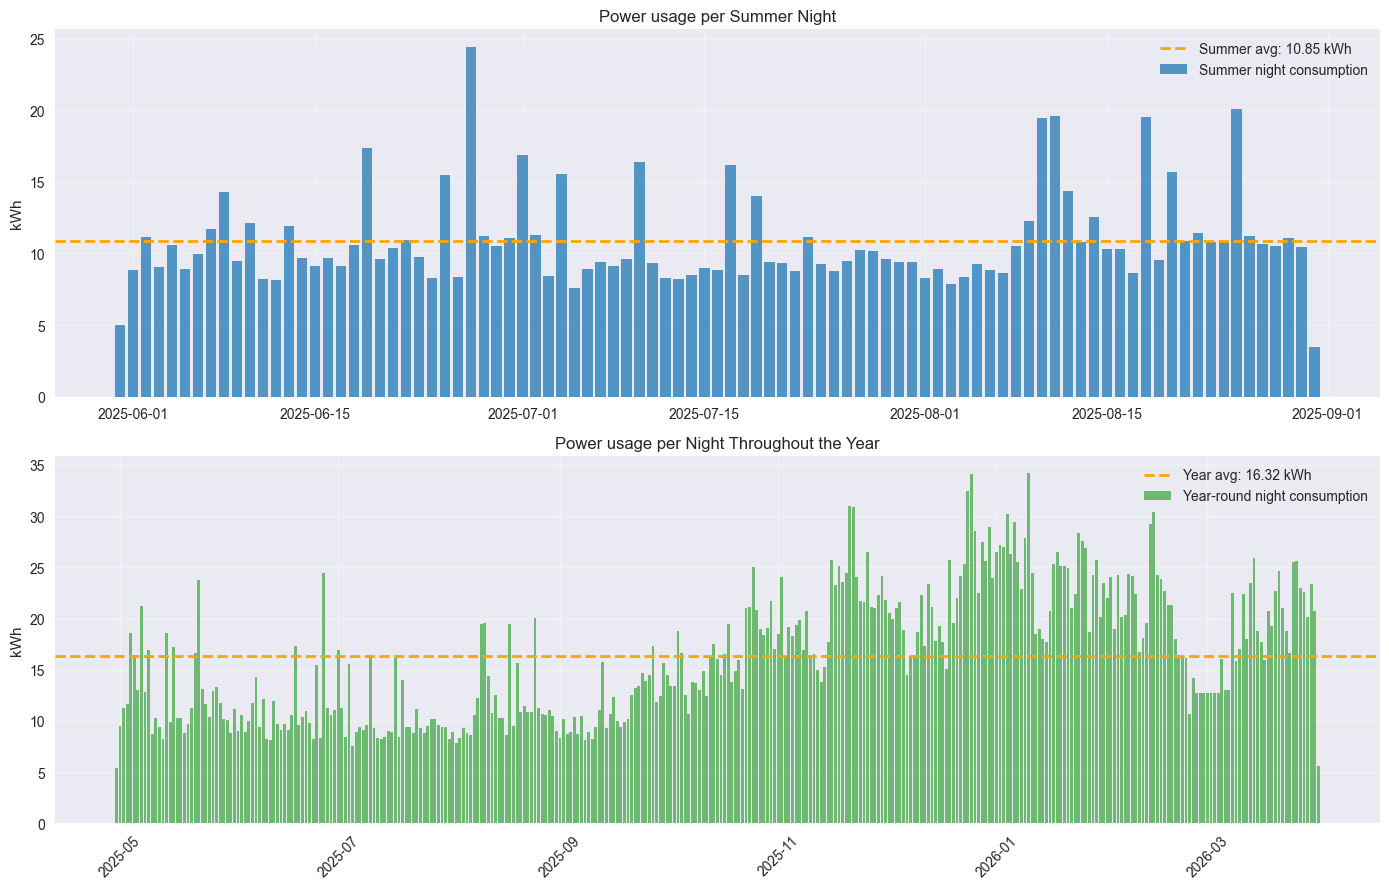

In [70]:
print("Average night battery need:", night_consumption.mean(), "kWh")
print("Median night battery need:", night_consumption.median(), "kWh")
print("Max night battery need:", night_consumption.max(), "kWh")
plt.figure(figsize=(14, 5))

df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour

def calculate_night_consumption(data, start_hour=21, end_hour=7):
    night = data[(data["hour"] >= start_hour) | (data["hour"] < end_hour)].copy()
    night["night_date"] = night["time"].dt.date
    night.loc[night["hour"] < end_hour, "night_date"] = (night.loc[night["hour"] < end_hour, "time"] - pd.Timedelta(days=1)).dt.date
    night_consumption = night.groupby("night_date")["Import net"].sum()
    return night_consumption

summer = df[df["month"].isin([6, 7, 8])].copy()
night_consumption_summer = calculate_night_consumption(summer, start_hour=21, end_hour=7)
night_consumption_year = calculate_night_consumption(df, start_hour=21, end_hour=7)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False, gridspec_kw={"height_ratios": [1, 1]})
ax1.bar(night_consumption_summer.index, night_consumption_summer.values, color="#1f77b4", alpha=0.75, label="Summer night consumption")
ax1.axhline(night_consumption_summer.mean(), color="orange", linestyle="--", linewidth=2, label=f"Summer avg: {night_consumption_summer.mean():.2f} kWh")
ax1.set_title("Power usage per Summer Night")
ax1.set_ylabel("kWh")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(night_consumption_year.index, night_consumption_year.values, color="#2ca02c", alpha=0.65, label="Year-round night consumption")
ax2.axhline(night_consumption_year.mean(), color="orange", linestyle="--", linewidth=2, label=f"Year avg: {night_consumption_year.mean():.2f} kWh")
ax2.set_title("Power usage per Night Throughout the Year")
ax2.set_ylabel("kWh")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()